In [1]:
# Install required packages
%pip install diffusers transformers accelerate torch torchvision torchaudio


In [2]:
import torch
from diffusers import StableDiffusionXLPipeline

# Load the stable diffusion XL base 1.0 model
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", 
    torch_dtype=torch.float16, 
    variant="fp16", 
    use_safetensors=True
)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe.to(device)

print(f"Model loaded on {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded on cuda


Generating image with prompt: 'a detailed photograph of a cat, looking at the camera, highly detailed, photorealistic'


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


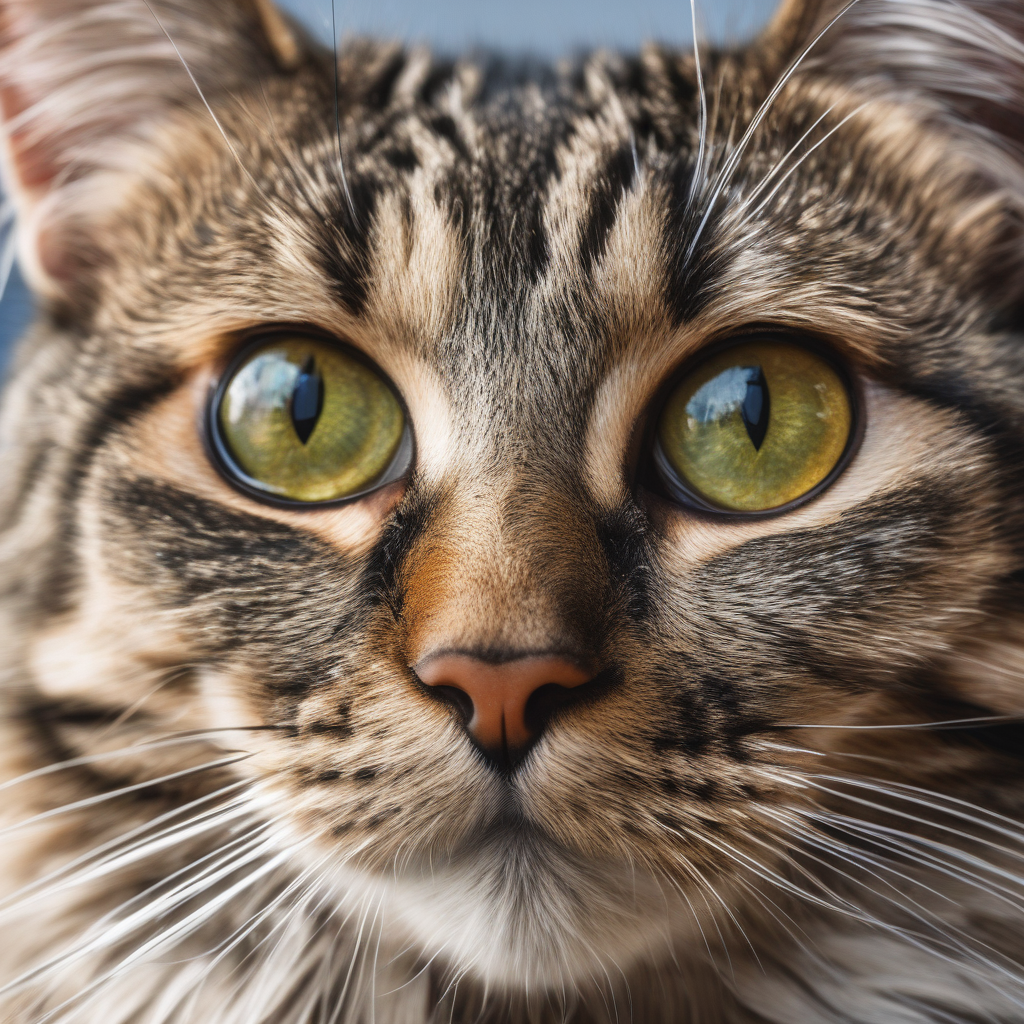

In [3]:
# Generate an image programmatically
prompt = "a detailed photograph of a cat, looking at the camera, highly detailed, photorealistic"
negative_prompt = "blurry, low quality, bad anatomy"

print(f"Generating image with prompt: '{prompt}'")
image = pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=25).images[0]

# Display the image
image